In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 130

# ---------- Helpers ----------
def sanitize_columns(df):
    """Lowercase columns; normalize spaces/punct -> underscores."""
    def fix(c):
        c = str(c).strip()
        c = re.sub(r"\s+", "_", c)
        c = re.sub(r"[^\w_]", "_", c)
        c = re.sub(r"_+", "_", c).strip("_")
        return c
    d = df.copy()
    d.columns = [fix(c.lower()) for c in d.columns]
    return d

def get_col(df, candidates):
    """Return the first existing column among candidates (case-insensitive)."""
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols:
            return cols[cand.lower()]
    return None

def parse_money(s):
    """
    Parse money-like strings to float (USD):
    '$1,234,567' -> 1234567
    '850M'/'850 million' -> 850_000_000
    '1.2B'/'1.2 billion' -> 1_200_000_000
    """
    if s is None:
        return np.nan
    x = str(s).strip().replace(",", "").replace("$", "").lower()
    if x in ("", "na", "n/a", "none"):
        return np.nan
    mult = 1.0
    if "b" in x or "billion" in x:
        mult = 1e9
        x = re.sub(r"[a-z]+", "", x)
    elif "m" in x or "million" in x:
        mult = 1e6
        x = re.sub(r"[a-z]+", "", x)
    try:
        return float(x) * mult
    except:
        num = re.findall(r"\d+(?:\.\d+)?", x)
        return float(num[0]) * mult if num else np.nan

def parse_duration_minutes(s):
    """
    Parse duration to minutes:
    '150' -> 150
    '150 min' -> 150
    '2h 10m' -> 130
    """
    if pd.isna(s):
        return np.nan
    x = str(s).lower().strip()
    # hh h mm m
    h = re.search(r"(\d+)\s*h", x)
    m = re.search(r"(\d+)\s*m", x)
    if h:
        hours = int(h.group(1))
        mins = int(m.group(1)) if m else 0
        return hours * 60 + mins
    # plain minutes (possibly with 'min')
    num = re.findall(r"\d+", x)
    return float(num[0]) if num else np.nan

def safe_distplot(data, kde=True):
    """
    Seaborn.distplot is deprecated in recent versions.
    Use histplot + kde overlay as a compatible fallback.
    """
    try:
        # Try the old API if available
        import warnings, seaborn as sns
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            sns.distplot(data, kde=kde)  # may not exist in latest seaborn
    except Exception:
        sns.histplot(data, kde=kde, bins=20)


In [2]:
from google.colab import files
uploaded = files.upload()  # select mcu_box_office.csv

fname = list(uploaded.keys())[0]
raw = pd.read_csv(fname)
df = sanitize_columns(raw)
print("Loaded:", fname, "| Shape:", df.shape)
display(df.head(3))
print("Columns:", df.columns.tolist())


Saving mcu_box_office.csv to mcu_box_office.csv
Loaded: mcu_box_office.csv | Shape: (27, 10)


,movie_title,mcu_phase,release_date,tomato_meter,audience_score,movie_duration,production_budget,opening_weekend,domestic_box_office,worldwide_box_office
0,Iron Man,1,5/2/2008,94,91,126,"186,000,000","102,118,668","318,604,126","585,171,547"
1,The Incredible Hulk,1,6/13/2008,67,70,112,"137,500,000","55,414,050","134,806,913","265,573,859"
2,Iron Man 2,1,5/7/2010,72,71,124,"170,000,000","128,122,480","312,433,331","621,156,389"


Columns: ['movie_title', 'mcu_phase', 'release_date', 'tomato_meter', 'audience_score', 'movie_duration', 'production_budget', 'opening_weekend', 'domestic_box_office', 'worldwide_box_office']


In [3]:
# Detect columns (robust to naming variants)
c_duration = get_col(df, ["movie_duration","duration","runtime","runtime_min","duration_min","running_time"])
c_tomato   = get_col(df, ["tomato_meter","tomatometer","tomato_meter_score","tomato_meter_percent","tomatometer_percent"])
c_aud      = get_col(df, ["audience_score","audience_rating","audience_meter","audience_meter_percent"])
c_budget   = get_col(df, ["production_budget","budget","prod_budget"])
c_opening  = get_col(df, ["opening_weekend","opening_weekend_us","opening_weekend_box_office","opening_weekend_gross"])
c_domestic = get_col(df, ["domestic_box_office","domestic","domestic_gross","domestic_box"])
c_world    = get_col(df, ["worldwide_box_office","worldwide","worldwide_gross","global_box_office","box_office_worldwide"])
c_date     = get_col(df, ["release_date","released","release"])
c_phase    = get_col(df, ["mcu_phase","phase","phase_name"])

print("Detected:")
print(" duration ->", c_duration)
print(" tomato   ->", c_tomato)
print(" audience ->", c_aud)
print(" budget   ->", c_budget)
print(" opening  ->", c_opening)
print(" domestic ->", c_domestic)
print(" worldwide->", c_world)
print(" date     ->", c_date)
print(" phase    ->", c_phase)

# Build working frame with canonical names
work = pd.DataFrame()

if c_duration: work["movie_duration_min"] = df[c_duration].apply(parse_duration_minutes)
if c_tomato:   work["tomato_meter"] = pd.to_numeric(df[c_tomato], errors="coerce")
if c_aud:      work["audience_score"] = pd.to_numeric(df[c_aud], errors="coerce")

if c_budget:   work["production_budget"]   = df[c_budget].apply(parse_money)
if c_opening:  work["opening_weekend"]     = df[c_opening].apply(parse_money)
if c_domestic: work["domestic_box_office"] = df[c_domestic].apply(parse_money)
if c_world:    work["worldwide_box_office"]= df[c_world].apply(parse_money)

if c_date:
    work["release_date"] = pd.to_datetime(df[c_date], errors="coerce", infer_datetime_format=True)

if c_phase:    work["mcu_phase"] = df[c_phase].astype(str)

# Drop duplicates
before = len(work)
work = work.drop_duplicates().reset_index(drop=True)
print(f"\nDropped duplicates: {before - len(work)}")

print("\nMissing values (top 10):")
display(work.isna().sum().sort_values(ascending=False).head(10).to_frame("missing"))

print("\nPreview:")
display(work.head())


Detected:
 duration -> movie_duration
 tomato   -> tomato_meter
 audience -> audience_score
 budget   -> production_budget
 opening  -> opening_weekend
 domestic -> domestic_box_office
 worldwide-> worldwide_box_office
 date     -> release_date
 phase    -> mcu_phase

Dropped duplicates: 0

Missing values (top 10):


/tmp/ipython-input-4023327151.py:36: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  work["release_date"] = pd.to_datetime(df[c_date], errors="coerce", infer_datetime_format=True)


,missing
movie_duration_min,0
tomato_meter,0
audience_score,0
production_budget,0
opening_weekend,0
domestic_box_office,0
worldwide_box_office,0
release_date,0
mcu_phase,0



Preview:


,movie_duration_min,tomato_meter,audience_score,production_budget,opening_weekend,domestic_box_office,worldwide_box_office,release_date,mcu_phase
0,126.0,94,91,186000000.0,102118668.0,318604126.0,585171547.0,2008-05-02,1
1,112.0,67,70,137500000.0,55414050.0,134806913.0,265573859.0,2008-06-13,1
2,124.0,72,71,170000000.0,128122480.0,312433331.0,621156389.0,2010-05-07,1
3,113.0,77,76,150000000.0,65723338.0,181030624.0,449326618.0,2011-05-06,1
4,124.0,79,75,140000000.0,65058524.0,176654505.0,370569776.0,2011-07-22,1


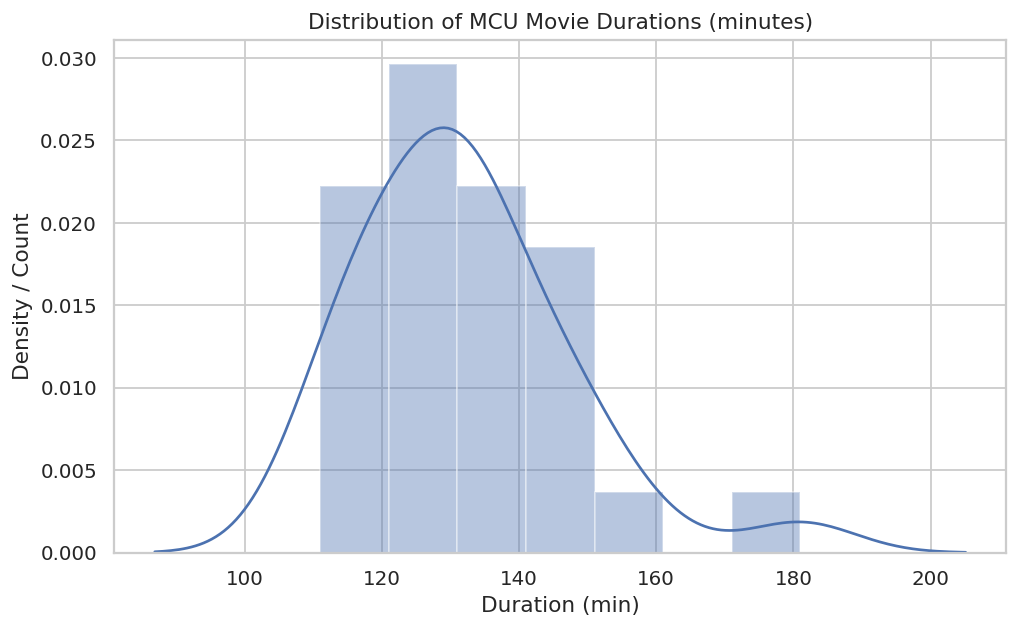

In [4]:
if "movie_duration_min" not in work.columns or work["movie_duration_min"].dropna().empty:
    raise ValueError("movie_duration column not found or empty after parsing.")

plt.figure(figsize=(8,5))
safe_distplot(work["movie_duration_min"].dropna(), kde=True)
plt.title("Distribution of MCU Movie Durations (minutes)")
plt.xlabel("Duration (min)")
plt.ylabel("Density / Count")
plt.tight_layout()
plt.show()


/tmp/ipython-input-4166671691.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=melted, x="score_type", y="score", palette="Set2")


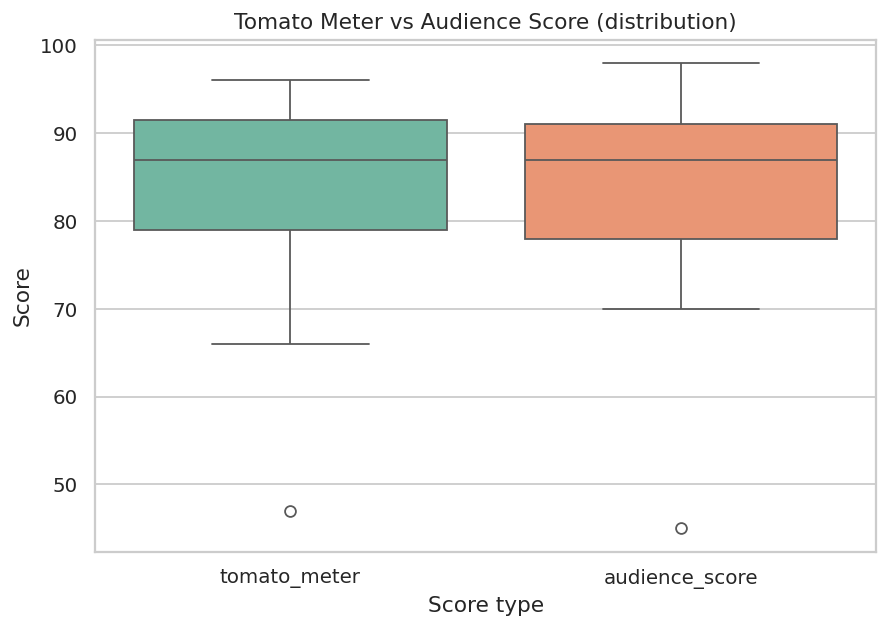

In [5]:
needed = []
if "tomato_meter" in work.columns and not work["tomato_meter"].dropna().empty:
    needed.append("tomato_meter")
if "audience_score" in work.columns and not work["audience_score"].dropna().empty:
    needed.append("audience_score")

if len(needed) < 2:
    raise ValueError("Need both Tomato Meter and Audience scores for the box plot.")

melted = work[needed].melt(var_name="score_type", value_name="score").dropna()

plt.figure(figsize=(7,5))
sns.boxplot(data=melted, x="score_type", y="score", palette="Set2")
plt.title("Tomato Meter vs Audience Score (distribution)")
plt.xlabel("Score type")
plt.ylabel("Score")
plt.tight_layout()
plt.show()


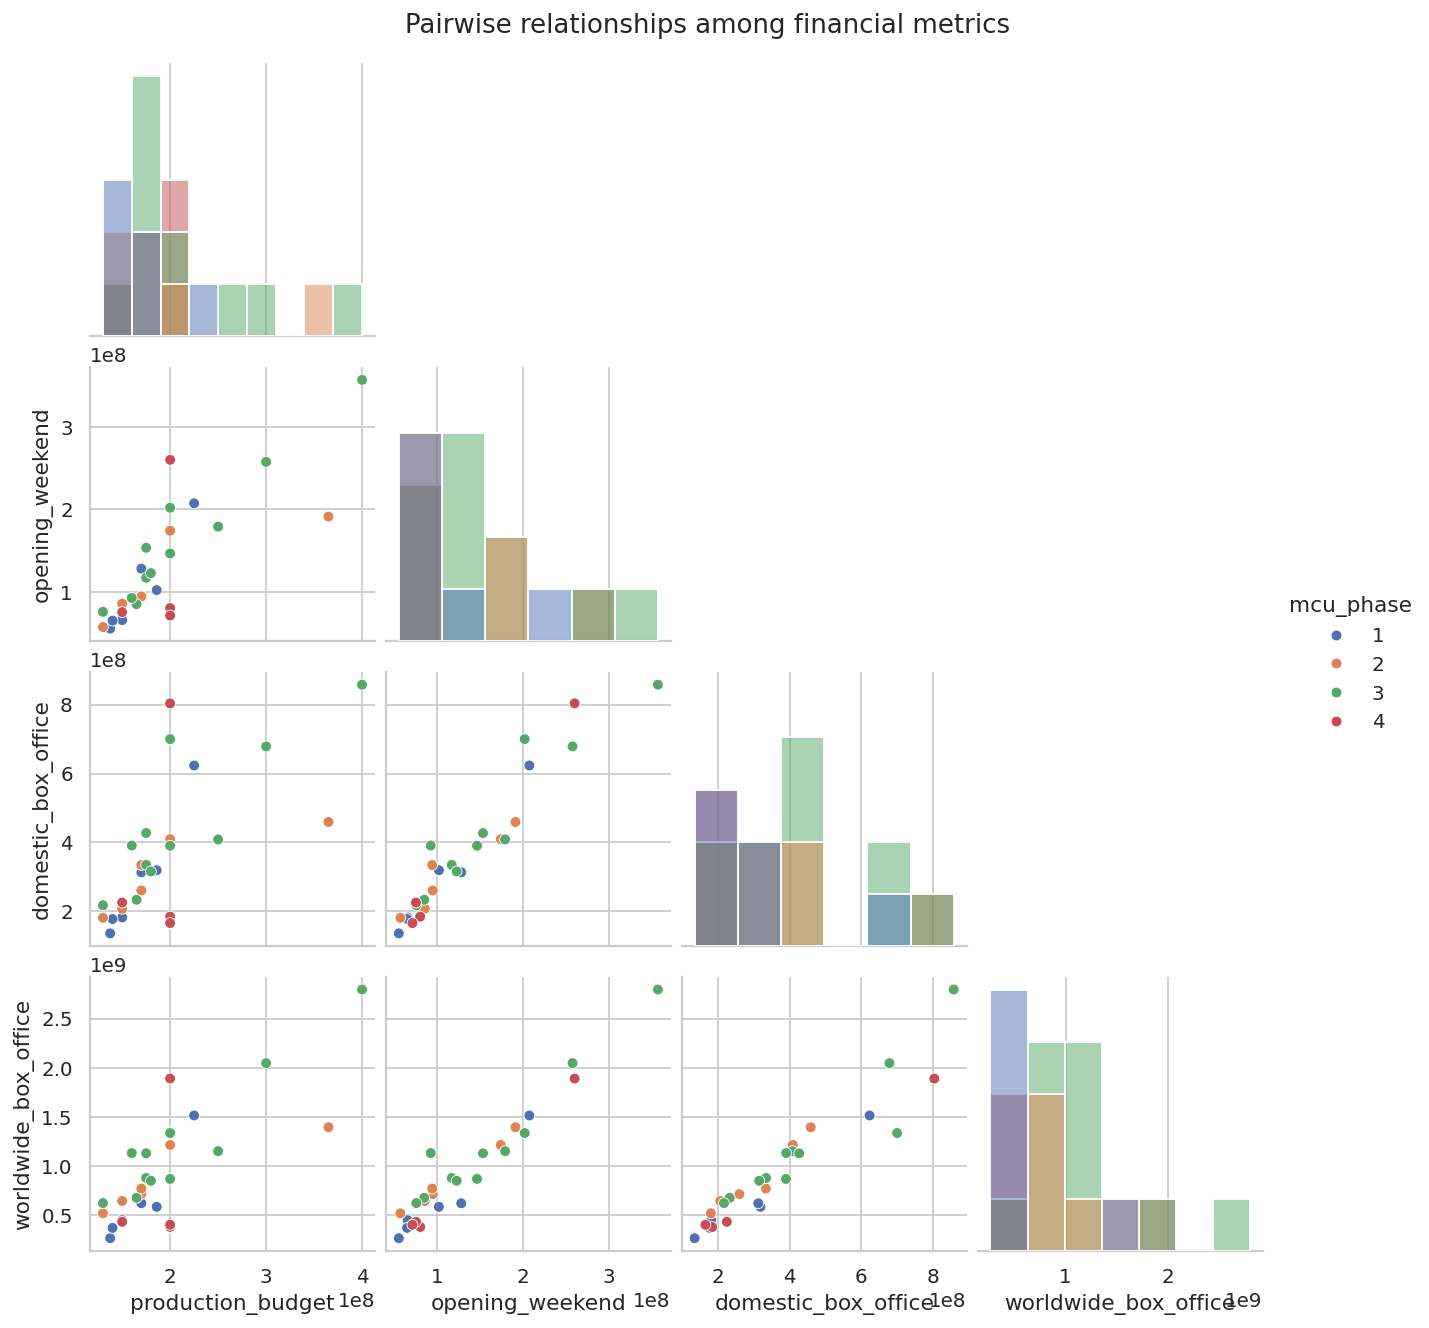

In [6]:
fin_cols = [c for c in ["production_budget","opening_weekend","domestic_box_office","worldwide_box_office"] if c in work.columns]
if len(fin_cols) < 2:
    raise ValueError("Need at least two financial columns for pairplot.")

pp = work[fin_cols + (["mcu_phase"] if "mcu_phase" in work.columns else [])].dropna()
hue = "mcu_phase" if "mcu_phase" in pp.columns else None

sns.pairplot(pp, vars=fin_cols, hue=hue, diag_kind="hist", corner=True)
plt.suptitle("Pairwise relationships among financial metrics", y=1.02)
plt.show()


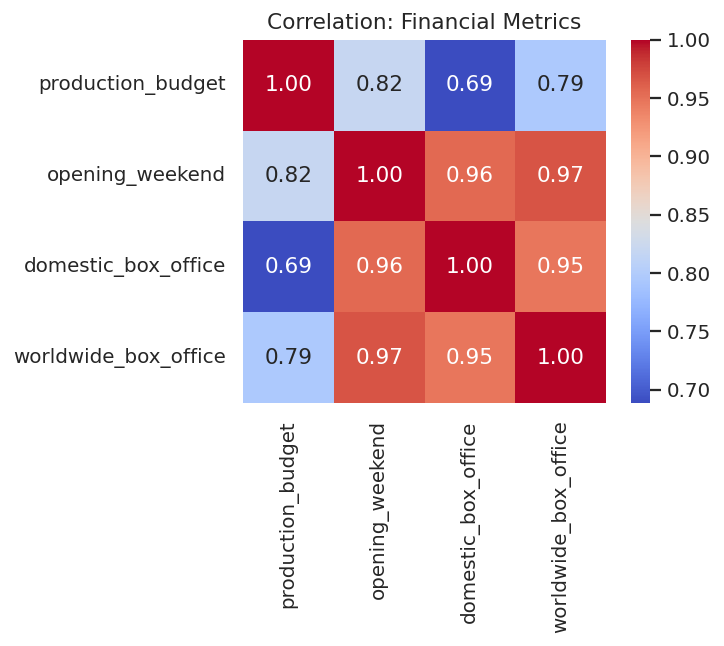

,production_budget,opening_weekend,domestic_box_office,worldwide_box_office
production_budget,1.000000,0.819052,0.688485,0.794979
opening_weekend,0.819052,1.000000,0.955359,0.967637
domestic_box_office,0.688485,0.955359,1.000000,0.946955
worldwide_box_office,0.794979,0.967637,0.946955,1.000000


In [7]:
corr_cols = [c for c in ["production_budget","opening_weekend","domestic_box_office","worldwide_box_office"] if c in work.columns]
if len(corr_cols) < 2:
    raise ValueError("Need at least two financial columns for correlation heatmap.")

corr = work[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation: Financial Metrics")
plt.tight_layout()
plt.show()

corr


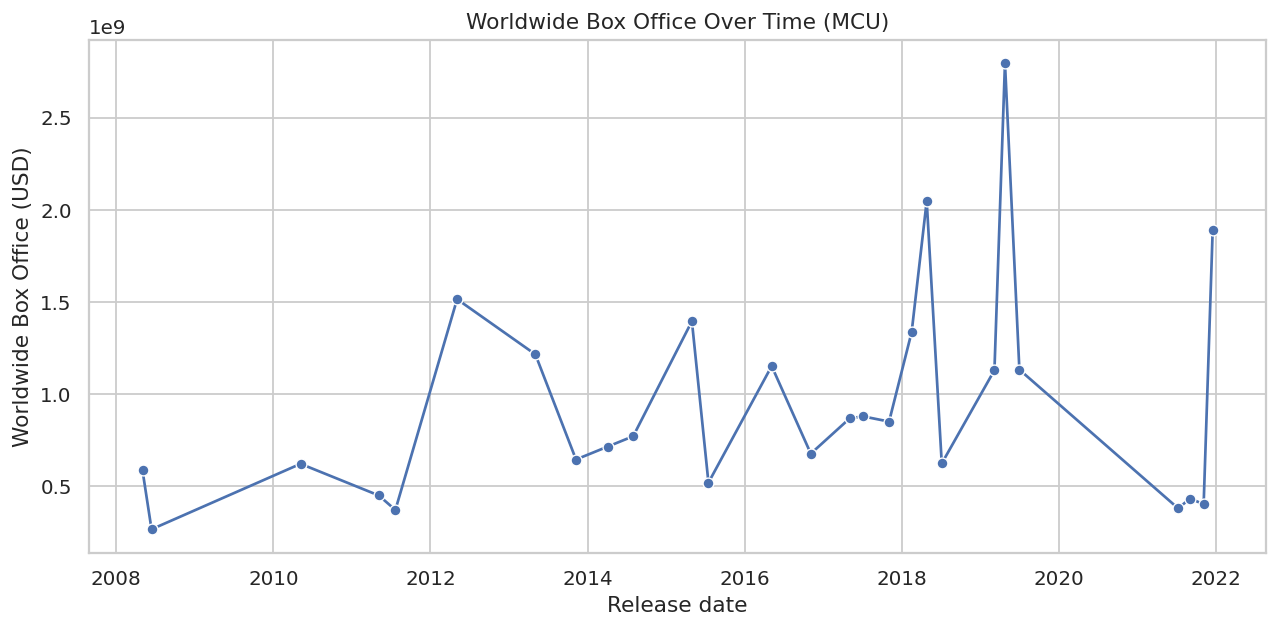

In [8]:
if "release_date" not in work.columns or work["release_date"].dropna().empty:
    raise ValueError("release_date is missing or not parseable.")

if "worldwide_box_office" not in work.columns:
    raise ValueError("worldwide_box_office is missing.")

ts = work.dropna(subset=["release_date","worldwide_box_office"]).sort_values("release_date")

plt.figure(figsize=(10,5))
sns.lineplot(data=ts, x="release_date", y="worldwide_box_office", marker="o")
plt.title("Worldwide Box Office Over Time (MCU)")
plt.xlabel("Release date")
plt.ylabel("Worldwide Box Office (USD)")
plt.tight_layout()
plt.show()


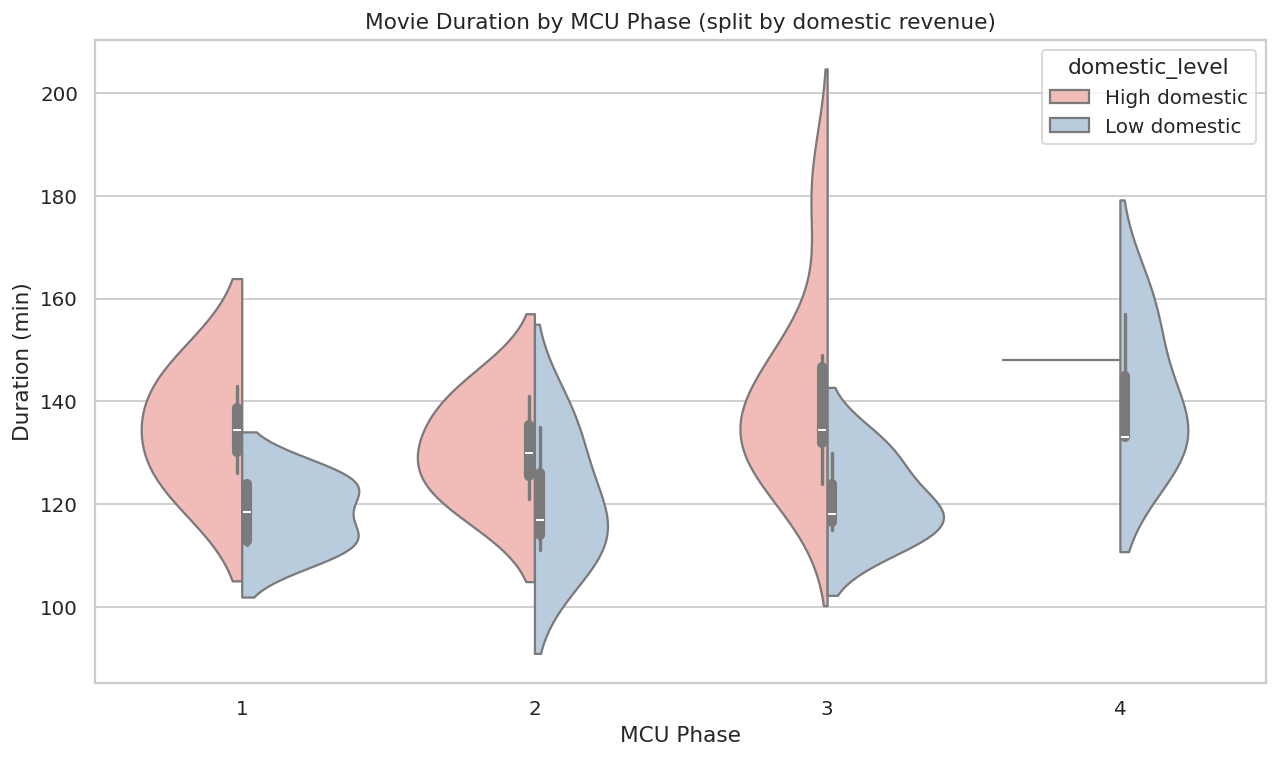

In [9]:
if "mcu_phase" not in work.columns:
    raise ValueError("mcu_phase column not found; required for the violin plot.")

if "movie_duration_min" not in work.columns or work["movie_duration_min"].dropna().empty:
    raise ValueError("movie_duration is missing or empty for violin plot.")

vdf = work.dropna(subset=["mcu_phase","movie_duration_min"]).copy()

# Optional: split by domestic high/low (median split)
if "domestic_box_office" in vdf.columns:
    med = vdf["domestic_box_office"].median()
    vdf["domestic_level"] = np.where(vdf["domestic_box_office"] >= med, "High domestic", "Low domestic")
    hue_col = "domestic_level"
else:
    hue_col = None

plt.figure(figsize=(10,6))
sns.violinplot(data=vdf, x="mcu_phase", y="movie_duration_min",
               hue=hue_col, split=True if hue_col else False, palette="Pastel1")
plt.title("Movie Duration by MCU Phase" + (" (split by domestic revenue)" if hue_col else ""))
plt.xlabel("MCU Phase")
plt.ylabel("Duration (min)")
plt.tight_layout()
plt.show()


nsights Summary
• Durations: MCU runtimes cluster around the 2-hour mark, with some longer ensemble entries.
• Scores: Audience vs Tomato Meter distributions can diverge—some titles are crowd-pleasers more than critic darlings (or vice versa).
• Financials: Production budget, opening weekend, domestic, and worldwide grosses are positively correlated; opening weekend often correlates strongly with total worldwide.
• Trend: Worldwide revenue generally grows with later phases (marketing scale, global markets), with outliers from event films.
• Phases: Violin plot shows how runtime distributions shift across phases; optional split hints how domestic performance relates to duration.
Caveats: Money values often missing or reported inconsistently; dataset scope limited to MCU titles; correlations are descriptive, not causal.